# Import Libraries & Load Dataset

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv("C:\\Users\\Lenovo\\Dissertation-folder\\thyroidDF.csv")

# Data Preprocessing

In [5]:
# Drop irrelevant columns
columns_to_drop = ['patient_id', 'TBG', 'TBG_measured', 'referral_source'] + \
                  [col for col in df.columns if '_measured' in col]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Drop rows with missing target
df = df[df['target'].notna()]

# Remove rare classes from target
target_counts = df['target'].value_counts()
valid_targets = target_counts[target_counts >= 10].index
df = df[df['target'].isin(valid_targets)]

In [6]:
# Handle missing values
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include='object').columns.drop('target')

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [7]:
# Encode categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode the target
target_encoder = LabelEncoder()
df['target'] = target_encoder.fit_transform(df['target'])

In [8]:
corr_matrix = df.corr()

In [9]:
# Split features and target
X = df.drop(columns='target')
y = df['target']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest Classifier

In [12]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
# Predict and evaluate
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_encoder.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9293924466338259

Classification Report:
               precision    recall  f1-score   support

           -       0.95      0.97      0.96      1355
           A       0.85      0.77      0.81        30
          AK       0.71      0.56      0.62         9
           B       0.00      0.00      0.00         4
         C|I       0.00      0.00      0.00         2
           F       0.90      1.00      0.95        47
           G       0.99      1.00      0.99        72
          GI       1.00      0.50      0.67         2
          GK       1.00      1.00      1.00        10
           I       0.81      0.74      0.77        69
           J       1.00      0.67      0.80         6
           K       0.86      0.95      0.90        87
          KJ       1.00      1.00      1.00         2
           L       0.73      0.70      0.71        23
           M       0.95      0.95      0.95        22
          MK       0.75      1.00      0.86         3
           N       0.78    

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


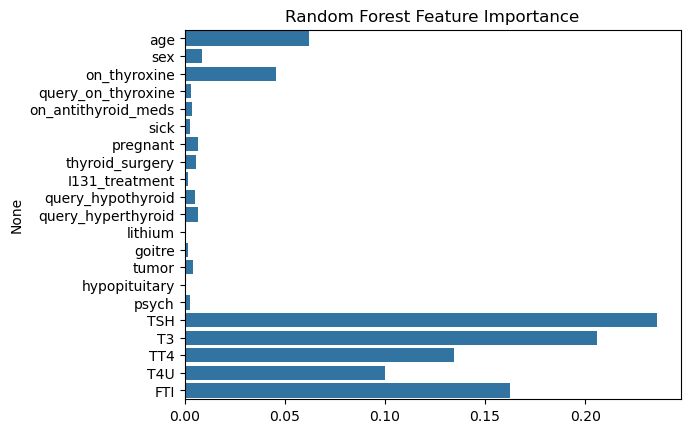

In [14]:
feature_importance = rf.feature_importances_
sns.barplot(x=feature_importance, y=X.columns)
plt.title("Random Forest Feature Importance")
plt.show()

# Support Vector Machine (SVM)

In [16]:
# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

SVC()

In [17]:
# Predict and evaluate
y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm, target_names=target_encoder.classes_))

SVM Accuracy: 0.8226600985221675

SVM Classification Report:
               precision    recall  f1-score   support

           -       0.84      0.98      0.91      1355
           A       0.68      0.50      0.58        30
          AK       0.00      0.00      0.00         9
           B       0.00      0.00      0.00         4
         C|I       1.00      0.50      0.67         2
           F       0.84      0.68      0.75        47
           G       0.87      0.28      0.42        72
          GI       0.00      0.00      0.00         2
          GK       1.00      0.10      0.18        10
           I       0.76      0.49      0.60        69
           J       0.00      0.00      0.00         6
           K       0.68      0.61      0.64        87
          KJ       0.00      0.00      0.00         2
           L       0.50      0.09      0.15        23
           M       0.57      0.18      0.28        22
          MK       0.00      0.00      0.00         3
           N       

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# XG Boost Classifier

In [19]:
# Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

C:\Users\Lenovo\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:28:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb, target_names=target_encoder.classes_))

XGBoost Accuracy: 0.9304871373836892

XGBoost Classification Report:
               precision    recall  f1-score   support

           -       0.96      0.97      0.96      1355
           A       0.83      0.83      0.83        30
          AK       0.80      0.44      0.57         9
           B       0.67      0.50      0.57         4
         C|I       1.00      0.50      0.67         2
           F       0.94      0.96      0.95        47
           G       0.99      0.94      0.96        72
          GI       0.00      0.00      0.00         2
          GK       0.91      1.00      0.95        10
           I       0.79      0.78      0.79        69
           J       1.00      0.67      0.80         6
           K       0.82      0.92      0.87        87
          KJ       1.00      1.00      1.00         2
           L       0.93      0.61      0.74        23
           M       0.91      0.95      0.93        22
          MK       0.50      0.33      0.40         3
           

# K-Nearest Neighbours

In [22]:
# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [23]:
# Predict and evaluate
y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn, target_names=target_encoder.classes_))

KNN Accuracy: 0.8352490421455939

KNN Classification Report:
               precision    recall  f1-score   support

           -       0.86      0.97      0.91      1355
           A       0.63      0.57      0.60        30
          AK       0.30      0.33      0.32         9
           B       0.00      0.00      0.00         4
         C|I       1.00      0.50      0.67         2
           F       0.85      0.74      0.80        47
           G       0.84      0.22      0.35        72
          GI       0.00      0.00      0.00         2
          GK       1.00      0.20      0.33        10
           I       0.77      0.58      0.66        69
           J       1.00      0.17      0.29         6
           K       0.73      0.62      0.67        87
          KJ       0.00      0.00      0.00         2
           L       0.38      0.22      0.28        23
           M       0.86      0.27      0.41        22
          MK       0.00      0.00      0.00         3
           N       

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Deep Neural Networks- MLP Classifier

In [25]:
# Initialize the model
mlp = MLPClassifier(hidden_layer_sizes=(128, 64),  # 2 hidden layers
                    activation='relu',
                    solver='adam',
                    alpha=0.0001,
                    batch_size='auto',
                    learning_rate='adaptive',
                    max_iter=300,
                    random_state=42)

In [26]:
# Train the model
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(128, 64), learning_rate='adaptive',
              max_iter=300, random_state=42)

In [27]:
# Predict
y_pred_mlp = mlp.predict(X_test)

# Evaluate
print("DNN (MLPClassifier) Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp, target_names=target_encoder.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))

DNN (MLPClassifier) Accuracy: 0.8888888888888888

Classification Report:
               precision    recall  f1-score   support

           -       0.93      0.95      0.94      1355
           A       0.62      0.77      0.69        30
          AK       0.50      0.11      0.18         9
           B       0.33      0.25      0.29         4
         C|I       0.50      0.50      0.50         2
           F       0.85      0.94      0.89        47
           G       0.91      0.81      0.85        72
          GI       0.50      0.50      0.50         2
          GK       0.83      1.00      0.91        10
           I       0.79      0.67      0.72        69
           J       1.00      0.67      0.80         6
           K       0.80      0.80      0.80        87
          KJ       1.00      0.50      0.67         2
           L       0.37      0.30      0.33        23
           M       0.90      0.86      0.88        22
          MK       0.60      1.00      0.75         3
       

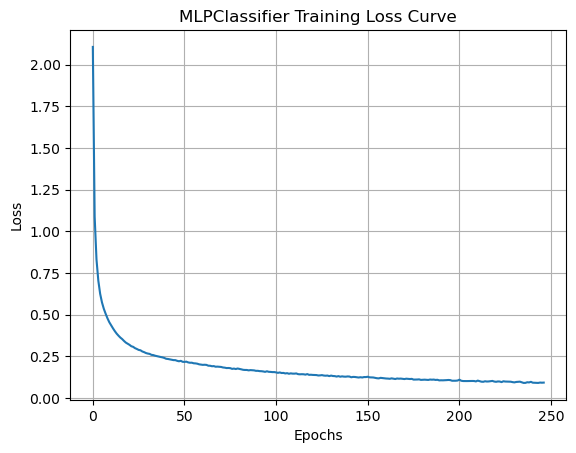

In [28]:
plt.plot(mlp.loss_curve_)
plt.title("MLPClassifier Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Logistic Regression

In [30]:
# Initialize the model
logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, random_state=42)

# Train the model
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=500, multi_class='multinomial', random_state=42)

In [31]:
# Predict on test data
y_pred_logreg = logreg.predict(X_test)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg, target_names=target_encoder.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.8412698412698413

Classification Report:
               precision    recall  f1-score   support

           -       0.87      0.97      0.92      1355
           A       0.75      0.60      0.67        30
          AK       0.40      0.22      0.29         9
           B       0.00      0.00      0.00         4
         C|I       0.00      0.00      0.00         2
           F       0.85      0.85      0.85        47
           G       0.72      0.43      0.54        72
          GI       0.00      0.00      0.00         2
          GK       0.88      0.70      0.78        10
           I       0.70      0.51      0.59        69
           J       0.25      0.17      0.20         6
           K       0.74      0.62      0.68        87
          KJ       0.00      0.00      0.00         2
           L       0.20      0.09      0.12        23
           M       0.81      0.59      0.68        22
          MK       1.00      0.33      0.50         3
       

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


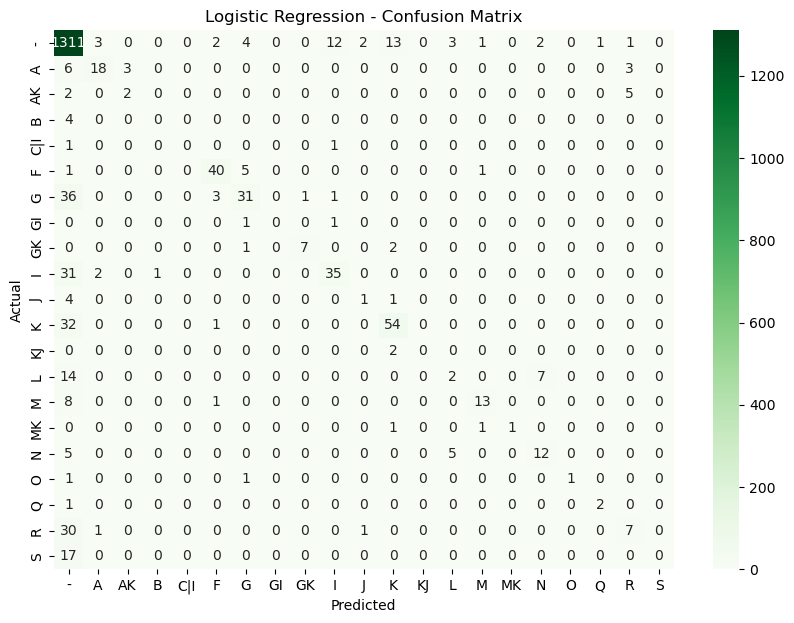

In [32]:
cm = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_encoder.classes_, 
            yticklabels=target_encoder.classes_)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Hybrid (ANN+CatBoost)

In [34]:
# Normalize data for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# Create and train a simple ANN model
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=300, random_state=42)

In [36]:
# Get ANN predictions (probabilities)
ann_train_features = ann_model.predict_proba(X_train_scaled)
ann_test_features = ann_model.predict_proba(X_test_scaled)

In [37]:
# Train CatBoost on ANN-generated features
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='Accuracy',
    verbose=0,
    random_seed=42
)

cat_model.fit(ann_train_features, y_train)

In [38]:
# Predict on test set
y_pred_hyb = cat_model.predict(ann_test_features)

Hybrid Model Accuracy: 0.8817733990147784

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      1355
           1       0.67      0.60      0.63        30
           2       0.44      0.44      0.44         9
           3       0.50      0.25      0.33         4
           4       1.00      0.50      0.67         2
           5       0.80      0.91      0.85        47
           6       0.89      0.76      0.82        72
           7       0.50      0.50      0.50         2
           8       1.00      1.00      1.00        10
           9       0.67      0.67      0.67        69
          10       0.60      0.50      0.55         6
          11       0.76      0.85      0.80        87
          12       0.00      0.00      0.00         2
          13       0.61      0.48      0.54        23
          14       0.80      0.73      0.76        22
          15       0.00      0.00      0.00         3
          16  

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


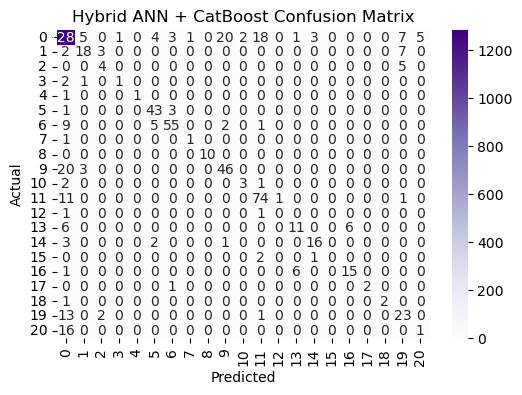

In [39]:
print("Hybrid Model Accuracy:", accuracy_score(y_test, y_pred_hyb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_hyb))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_hyb), annot=True, fmt='d', cmap='Purples')
plt.title("Hybrid ANN + CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Artificial Neural Networks

In [41]:
# ANN-only accuracy
y_pred_ann = ann_model.predict(X_test_scaled)
acc_ann = accuracy_score(y_test, y_pred_ann)

# Catboost

In [43]:
# CatBoost-only accuracy
cat_only = CatBoostClassifier(verbose=0, random_seed=42)
cat_only.fit(X_train_scaled, y_train)
y_pred_cat = cat_only.predict(X_test_scaled)
acc_cat = accuracy_score(y_test, y_pred_cat)

In [44]:
# Hybrid accuracy
acc_hybrid = accuracy_score(y_test, y_pred)

print(pd.DataFrame({
    "Model": ["ANN", "CatBoost", "Hybrid (ANN+CatBoost)"],
    "Accuracy": [acc_ann, acc_cat, acc_hybrid]
}))

                   Model  Accuracy
0                    ANN  0.880679
1               CatBoost  0.940887
2  Hybrid (ANN+CatBoost)  0.929392


# Visualize the Models Performance

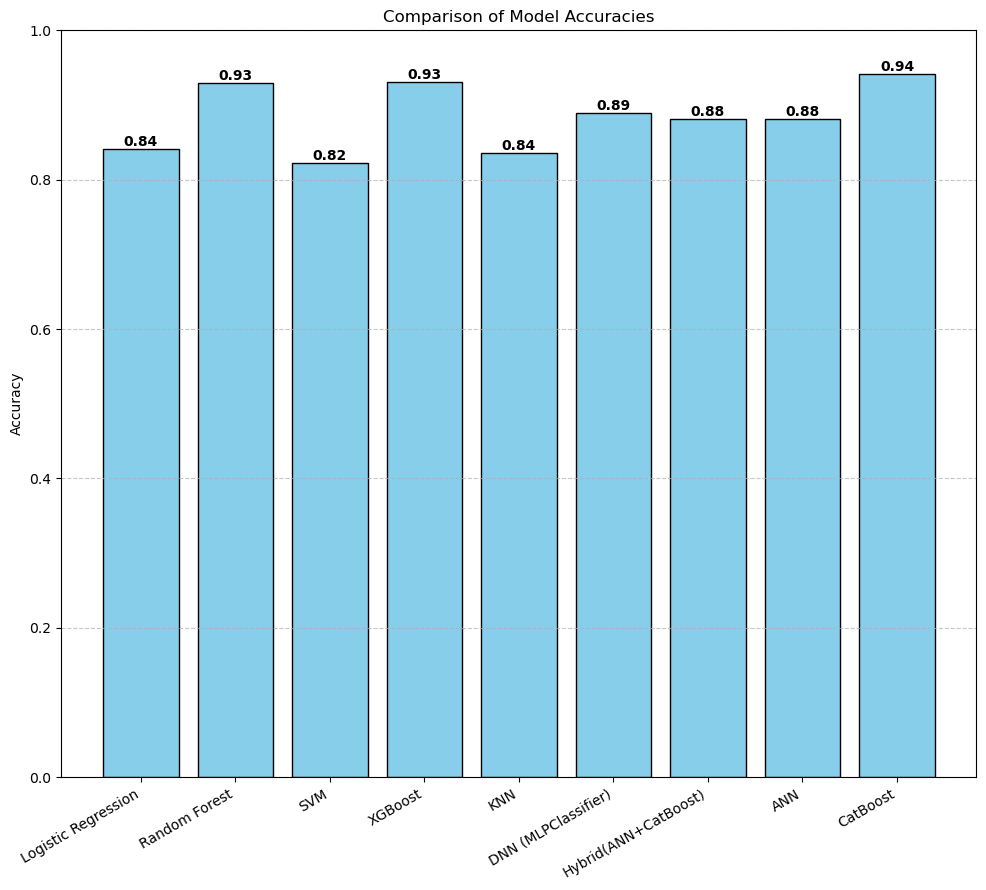

In [46]:
# Define model names and corresponding accuracies
model_names = ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost', 'KNN', 'DNN (MLPClassifier)', 'Hybrid(ANN+CatBoost)', 'ANN', 'CatBoost']
accuracies = [
    accuracy_score(y_test, y_pred_logreg),    # Logistic Regression
    accuracy_score(y_test, y_pred),           # Random Forest
    accuracy_score(y_test, y_pred_svm),       # SVM
    accuracy_score(y_test, y_pred_xgb),       # XGBoost
    accuracy_score(y_test, y_pred_knn),       # KNN
    accuracy_score(y_test, y_pred_mlp),       # DNN (Scikit-learn MLPClassifier)
    accuracy_score(y_test, y_pred_hyb),       # Hybrid(ANN + CatBoost)
    accuracy_score(y_test, y_pred_ann),       # ANN
    accuracy_score(y_test, y_pred_cat)        # CatBoost
]

# Plotting
plt.figure(figsize=(10, 9))
bars = plt.bar(model_names, accuracies, color='skyblue', edgecolor='black')
plt.ylim(0, 1)
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with accuracy values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# Data Visualisation & EDA

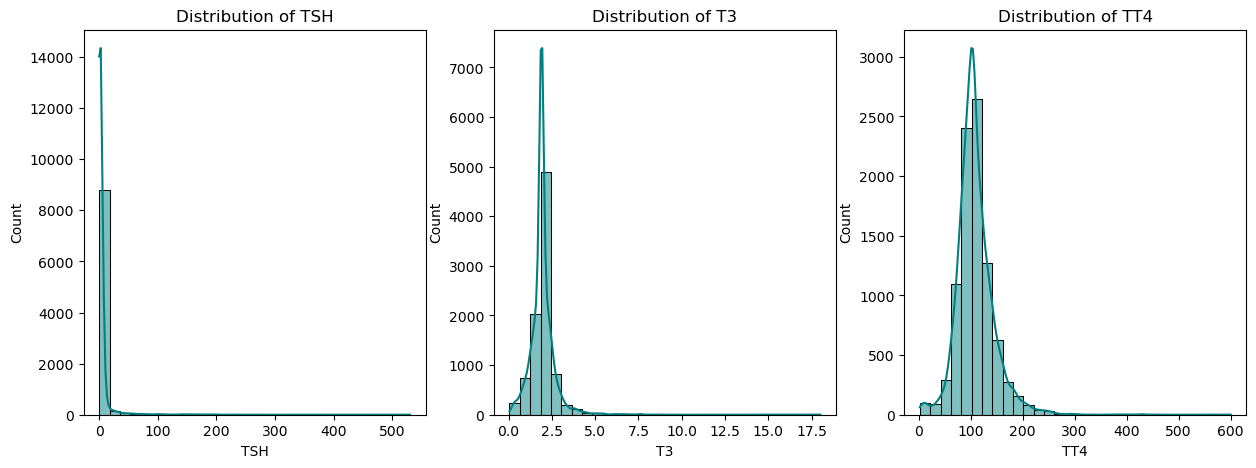

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11004\1347639712.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='coolwarm')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11004\1347639712.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='coolwarm')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11004\1347639712.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='coolwarm')


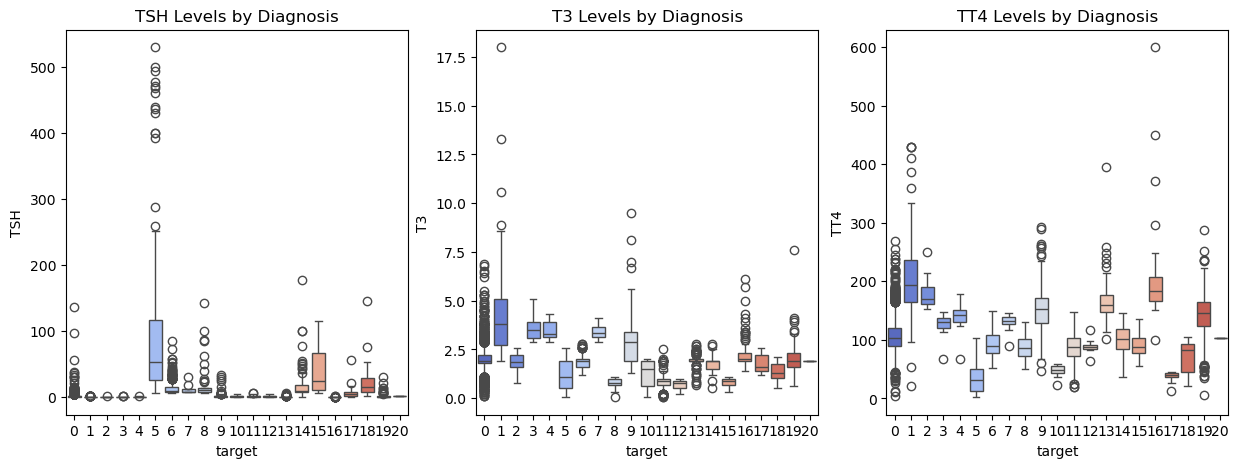

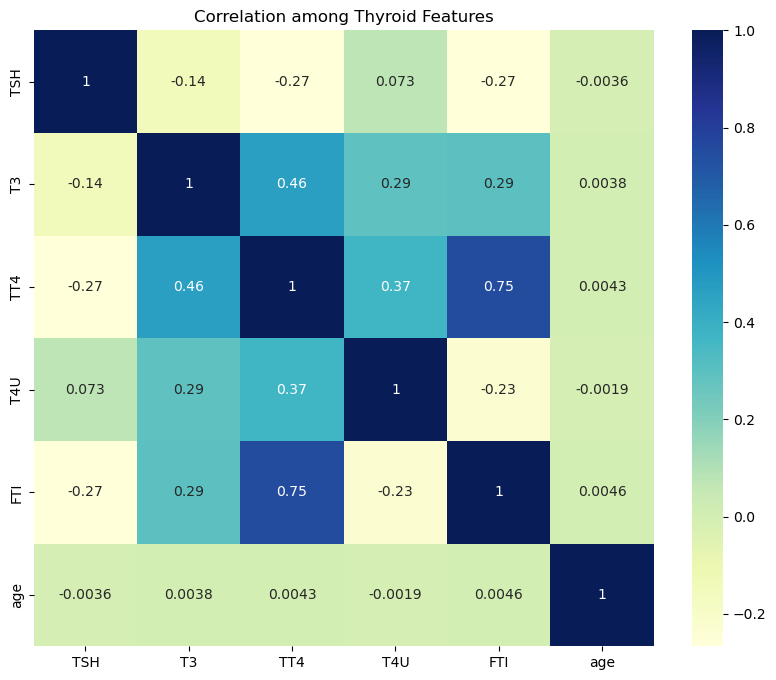

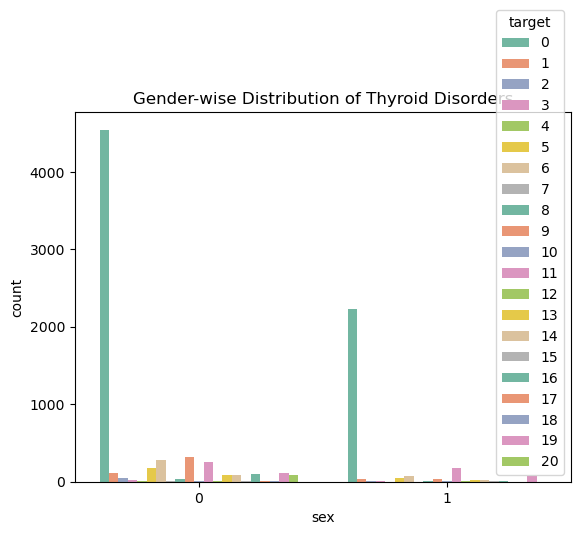

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11004\1347639712.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


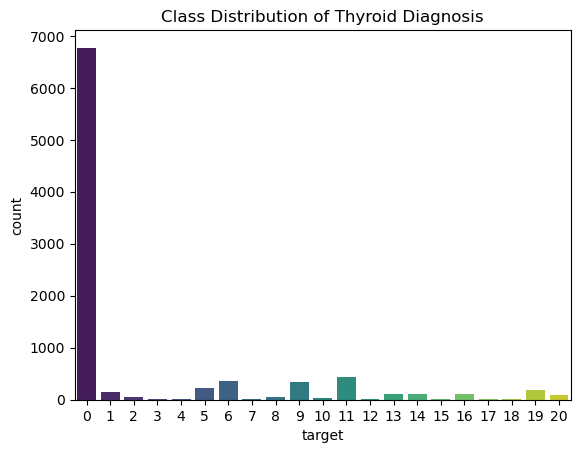

In [48]:
# Histogram for hormone distributions
plt.figure(figsize=(15,5))
for i, feature in enumerate(['TSH', 'T3', 'TT4']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[feature], bins=30, kde=True, color='teal')
    plt.title(f'Distribution of {feature}')
plt.show()

# Boxplots by diagnosis
plt.figure(figsize=(15,5))
for i, feature in enumerate(['TSH', 'T3', 'TT4']):
    plt.subplot(1,3,i+1)
    sns.boxplot(x='target', y=feature, data=df, palette='coolwarm')
    plt.title(f'{feature} Levels by Diagnosis')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[['TSH','T3','TT4','T4U','FTI','age']].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation among Thyroid Features')
plt.show()

# Gender vs Diagnosis
sns.countplot(x='sex', hue='target', data=df, palette='Set2')
plt.title('Gender-wise Distribution of Thyroid Disorders')
plt.show()

# Target Class Distribution
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Class Distribution of Thyroid Diagnosis')
plt.show()
